# FM phase-diagram fit playground

Interactive exploration of the Fredenhagen–Marcu curves extracted by
`Three_TC/fm.py` (pulled to `results/phase_hx*_*/`). Self-contained —
**pure numpy/scipy/matplotlib, no NetKet** — so it runs locally.

What you can do (all driven from the **CONFIG** cell):
- **drop bad points per L** (`EXCLUDE = {L: [hz, ...]}`) — e.g. collapsed runs;
- **restrict an hz window** applied to every L (`HZ_WINDOW`);
- **swap the per-L transition fit** form (`logistic | tanh | erf`);
- **swap the FSS form** for `h_c(L)` — including your `h0 + (b/L)**x` — and read
  off `h_0`; compare `h_0` across *all* forms in one table;
- fit **O_FM or ⟨σz⟩**, weight by errorbars, subset which L enter the FSS, fix the
  FSS exponent, and jackknife (leave-one-L-out) `h_0` for a stability estimate.

Re-run from the CONFIG cell down after any change.

In [10]:
%matplotlib inline
import glob, json, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

## 1 · CONFIG — the one cell to edit

In [11]:
# ---- data ------------------------------------------------------------------
DATA_DIR = "/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/results/phase_hx0.0_bulk"
OBS      = "O"          # "O" = O_FM   |   "mz" = <sigma_z>

# ---- point selection -------------------------------------------------------
# EXCLUDE  = {6: [0.24, 0.36]}   # {L: [hz, ...]} bad/collapsed points to drop
EXCLUDE = {}
HZ_WINDOW = None               # None, or (lo, hi) hz window applied to every L

# ---- per-L transition fit --------------------------------------------------
PERL_FORM = "logistic"         # "logistic" | "tanh" | "erf"  (h_c = inflection)

# ---- finite-size scaling of h_c(L) -----------------------------------------
#   linear_invL : h0 + a/L               (2 params)
#   power_x     : h0 + (b/L)**x          (3 params; your form)
#   power_free  : h0 + a*L**(-w)         (3 params; a = b**x reparam, better conditioned)
FSS_FORM  = "power_x"
FSS_FIX_X = None               # float -> FIX the exponent (x or w); frees a dof
FSS_LS    = None               # e.g. [4,5,6] subset of L for the FSS (None = all)

# ---- shared ----------------------------------------------------------------
WEIGHTED  = True               # use the fit errorbars as curve_fit sigma

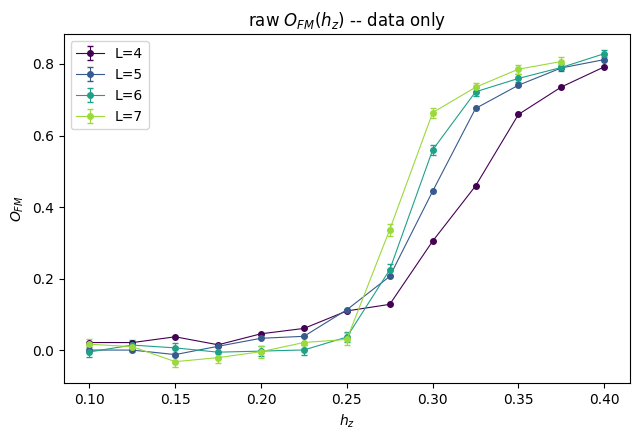

In [12]:
# quick look -- raw O_FM(h_z) points for every L in DATA_DIR (no fit, no exclusions).
# Self-contained (globs DATA_DIR itself) so it runs right after the CONFIG cell,
# before the load/fit machinery below.
_recs = sorted((json.load(open(jp))
                for jp in glob.glob(os.path.join(DATA_DIR, "fm_L*.json"))),
               key=lambda r: r["L"])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for rec, c in zip(_recs, plt.cm.viridis(np.linspace(0, 0.85, max(len(_recs), 1)))):
    hz = np.array(rec["field"], float)
    O  = np.array(rec["O"], float)
    Oe = np.array(rec.get("Oe", np.zeros_like(O)), float)
    ax.errorbar(hz, O, yerr=Oe, fmt="-o", ms=4, capsize=2, lw=0.8, color=c,
                label=f"L={rec['L']}")
ax.set(xlabel="$h_z$", ylabel="$O_{FM}$", title="raw $O_{FM}(h_z)$ -- data only")
ax.legend(); plt.tight_layout(); plt.show()

## 2 · Load + point selection

In [13]:
def load_curves(directory):
    recs = [json.load(open(jp))
            for jp in sorted(glob.glob(os.path.join(directory, "fm_L*.json")))]
    if not recs:
        raise SystemExit(f"no fm_L*.json in {directory} — pull the extracted curves first")
    return sorted(recs, key=lambda r: r["L"])

def get_arrays(rec, obs=None, exclude=None, window=None):
    """(hz, y, ye) for one L after applying EXCLUDE + HZ_WINDOW."""
    obs = OBS if obs is None else obs
    exclude = EXCLUDE if exclude is None else exclude
    window = HZ_WINDOW if window is None else window
    hz = np.array(rec["field"], float)
    y  = np.array(rec[obs], float)
    ye = np.array(rec.get("Oe" if obs == "O" else "mz_e", np.zeros_like(y)), float)
    keep = np.ones(len(hz), bool)
    for h in exclude.get(rec["L"], []):
        keep &= ~np.isclose(hz, h, atol=1e-6)
    if window is not None:
        keep &= (hz >= window[0]) & (hz <= window[1])
    return hz[keep], y[keep], ye[keep]

recs = load_curves(DATA_DIR)
_r0 = recs[0]
print(f"loaded L = {[r['L'] for r in recs]}   "
      f"placement = {_r0.get('placement','?')}   hx = {_r0.get('hx','?')}   obs = {OBS}")
for r in recs:
    hz, y, ye = get_arrays(r)
    print(f"  L={r['L']}: {len(hz):2d} pts kept "
          f"(dropped {len(r['field']) - len(hz)})   hz in [{hz.min():.3g}, {hz.max():.3g}]")

loaded L = [4, 5, 6, 7]   placement = bulk   hx = 0.0   obs = O
  L=4: 13 pts kept (dropped 0)   hz in [0.1, 0.4]
  L=5: 13 pts kept (dropped 0)   hz in [0.1, 0.4]
  L=6: 13 pts kept (dropped 0)   hz in [0.1, 0.4]
  L=7: 12 pts kept (dropped 0)   hz in [0.1, 0.375]


## 3 · Per-L transition fit

  L  npts      h_c  h_c_err   hc_fd   width
  4    13   0.3189   0.0026   0.338  0.0263
  5    13   0.2957   0.0016   0.287  0.0210
  6    13   0.2886   0.0010   0.287  0.0150
  7    12   0.2791   0.0010   0.287  0.0124


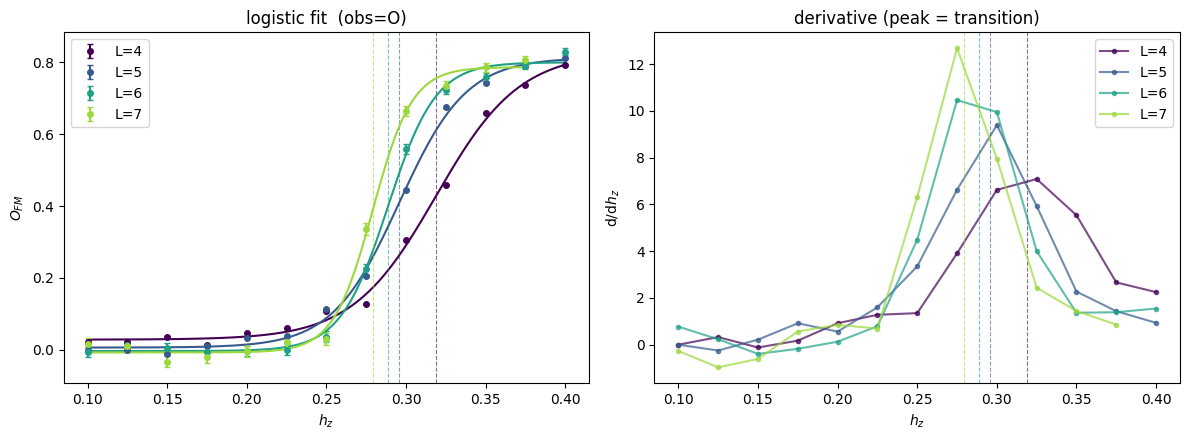

In [14]:
# --- sigmoid family: all have an inflection at h0 (= the pseudo-critical field) ---
def _logistic(h, a, b, h0, w): return a + b / (1.0 + np.exp(-(h - h0) / w))
def _tanh(h, a, b, h0, w):     return a + b * np.tanh((h - h0) / w)
def _erf(h, a, b, h0, w):      return a + b * erf((h - h0) / w)
PERL = {"logistic": _logistic, "tanh": _tanh, "erf": _erf}

def _p0(form, hz, y):
    rng = (hz[-1] - hz[0]) or 1.0
    if form == "logistic":
        return [y[0], y[-1] - y[0], float(np.median(hz)), 0.1 * rng]
    return [0.5 * (y[0] + y[-1]), 0.5 * (y[-1] - y[0]), float(np.median(hz)), 0.1 * rng]

def fit_transition(hz, y, ye, form=None, weighted=None):
    """Fit the chosen sigmoid; return h_c (= inflection h0), its error, curve, width,
    and a model-free finite-difference derivative-peak cross-check."""
    form = PERL_FORM if form is None else form
    weighted = WEIGHTED if weighted is None else weighted
    f = PERL[form]
    kw = dict(sigma=ye, absolute_sigma=True) if (weighted and np.all(ye > 0)) else {}
    popt, pcov = curve_fit(f, hz, y, p0=_p0(form, hz, y), maxfev=40000, **kw)
    hh = np.linspace(hz.min(), hz.max(), 400)
    hm = 0.5 * (hz[1:] + hz[:-1]); d = np.diff(y) / np.diff(hz)
    hc_fd = float(hm[int(np.argmax(np.abs(d)))]) if len(hm) else float("nan")
    return dict(popt=popt, h_c=float(popt[2]), h_c_err=float(np.sqrt(abs(pcov[2, 2]))),
                width=abs(float(popt[3])), hc_fd=hc_fd, curve=(hh, f(hh, *popt)))

fits = {}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(recs)))
ylab = r"$O_{FM}$" if OBS == "O" else r"$\langle\sigma_z\rangle$"
print(f"{'L':>3} {'npts':>5} {'h_c':>8} {'h_c_err':>8} {'hc_fd':>7} {'width':>7}")
for rec, c in zip(recs, colors):
    L = rec["L"]
    hz, y, ye = get_arrays(rec)
    fit = fit_transition(hz, y, ye); fits[L] = fit
    ax[0].errorbar(hz, y, yerr=ye, fmt="o", ms=4, capsize=2, color=c, label=f"L={L}")
    hh, yy = fit["curve"]; ax[0].plot(hh, yy, "-", color=c)
    ax[0].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
    ax[1].plot(hz, np.gradient(y, hz), "o-", ms=3, color=c, alpha=0.7, label=f"L={L}")
    ax[1].axvline(fit["h_c"], ls="--", color=c, lw=0.8, alpha=0.6)
    print(f"{L:>3} {len(hz):>5} {fit['h_c']:>8.4f} {fit['h_c_err']:>8.4f} "
          f"{fit['hc_fd']:>7.3f} {fit['width']:>7.4f}")
ax[0].set(xlabel="$h_z$", ylabel=ylab, title=f"{PERL_FORM} fit  (obs={OBS})"); ax[0].legend()
ax[1].set(xlabel="$h_z$", ylabel="d/d$h_z$", title="derivative (peak = transition)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Orientation isotropy check (bulk placement only)

If the curves carry per-plane data (`O_planes` from the bulk 3-plane average),
overlay the xy/xz/yz FM ratios against their mean. Tight agreement ⇒ the loop is
seeing an isotropic bulk; a fanned-out plane flags anisotropy / a bad orientation.

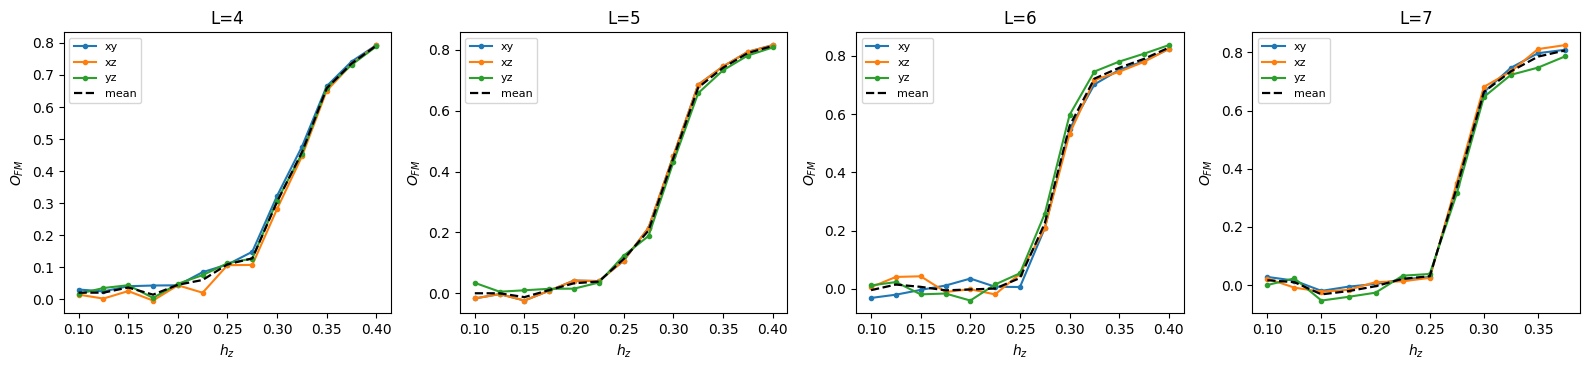

In [15]:
have = [r for r in recs if "O_planes" in r]
if have:
    fig, axs = plt.subplots(1, len(have), figsize=(4 * len(have), 3.8), squeeze=False)
    for axp, rec in zip(axs[0], have):
        hz = np.array(rec["field"], float)
        keep = np.ones(len(hz), bool)
        for h in EXCLUDE.get(rec["L"], []):
            keep &= ~np.isclose(hz, h, atol=1e-6)
        for lbl, ys in rec["O_planes"].items():
            axp.plot(hz[keep], np.array(ys, float)[keep], "o-", ms=3, label=lbl)
        axp.plot(hz[keep], np.array(rec["O"], float)[keep], "k--", lw=1.6, label="mean")
        axp.set(title=f"L={rec['L']}", xlabel="$h_z$", ylabel="$O_{FM}$"); axp.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("no O_planes in these curves (boundary placement or legacy) — nothing to compare")

## 5 · Finite-size scaling  →  h₀

FSS form = power_x   dof = 1
  params: {'h0': 0.2515, 'b': 0.6603, 'x': 1.5103}
  ==>  h_0 = 0.2515 ± 0.0183


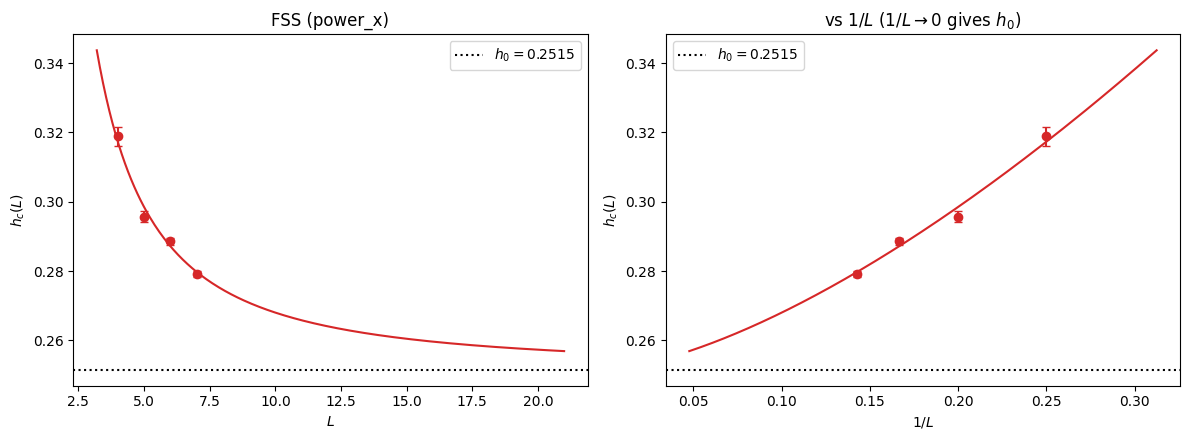

In [16]:
def fss_linear(L, h0, a):       return h0 + a / np.asarray(L, float)
def fss_power_x(L, h0, b, x):   return h0 + (b / np.asarray(L, float)) ** x
def fss_power_free(L, h0, a, w): return h0 + a * np.asarray(L, float) ** (-w)
FSS = {  # name -> (func, param_names, p0)
    "linear_invL": (fss_linear,     ["h0", "a"],      [0.25, 0.5]),
    "power_x":     (fss_power_x,    ["h0", "b", "x"], [0.25, 3.0, 1.0]),
    "power_free":  (fss_power_free, ["h0", "a", "w"], [0.25, 0.5, 1.0]),
}

def fit_fss(fits, form=None, use_Ls=None, fix_x=None, weighted=None, verbose=True):
    """Fit h_c(L) with the chosen form. Returns a dict incl. h0, h0_err, popt, dof,
    and a smooth curve. `fix_x` pins the exponent (power forms) to free a dof."""
    form = FSS_FORM if form is None else form
    use_Ls = FSS_LS if use_Ls is None else use_Ls
    fix_x = FSS_FIX_X if fix_x is None else fix_x
    weighted = WEIGHTED if weighted is None else weighted
    Ls = sorted(fits) if use_Ls is None else sorted(use_Ls)
    L  = np.array(Ls, float)
    hc = np.array([fits[l]["h_c"] for l in Ls])
    he = np.array([fits[l]["h_c_err"] for l in Ls])
    f, names, p0 = FSS[form]
    kw = dict(sigma=he, absolute_sigma=True) if (weighted and np.all(he > 0)) else {}
    fixed = fix_x is not None and form in ("power_x", "power_free")
    try:
        if fixed:
            g = lambda LL, h0, p2: f(LL, h0, p2, fix_x)
            popt2, pcov2 = curve_fit(g, L, hc, p0=p0[:2], maxfev=40000, **kw)
            popt = np.array([popt2[0], popt2[1], fix_x]); h0e = float(np.sqrt(abs(pcov2[0, 0])))
            nfree = 2
        else:
            popt, pcov = curve_fit(f, L, hc, p0=p0, maxfev=40000, **kw)
            h0e = float(np.sqrt(abs(pcov[0, 0]))); nfree = len(p0)
    except Exception as exc:
        if verbose: print(f"[fss:{form}] fit failed: {exc}")
        return dict(form=form, Ls=Ls, L=L, hc=hc, he=he, h0=float("nan"),
                    h0_err=float("nan"), popt=None, dof=len(L) - (2 if fixed else len(p0)))
    dof = len(L) - nfree
    if verbose and dof <= 0:
        print(f"[fss:{form}] WARNING dof={dof}: {len(L)} L-points vs {nfree} free params "
              f"-> exact/underdetermined, h0_err is not meaningful. "
              f"Use linear_invL, FSS_FIX_X, or add more L.")
    LL = np.linspace(L.min() * 0.8, L.max() * 3.0, 300)   # positive -> no 1/0 in the curve
    return dict(form=form, Ls=Ls, L=L, hc=hc, he=he, h0=float(popt[0]), h0_err=h0e,
                popt=popt, names=names, dof=dof, curve=(LL, f(LL, *popt)))

res = fit_fss(fits)
print(f"FSS form = {res['form']}   dof = {res['dof']}")
if res["popt"] is not None:
    print("  params:", {n: round(float(v), 4) for n, v in zip(res["names"], res["popt"])})
print(f"  ==>  h_0 = {res['h0']:.4f} ± {res['h0_err']:.4f}")

# plot h_c(L) vs 1/L with the fit curve and the h_0 asymptote
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].errorbar(res["L"], res["hc"], yerr=res["he"], fmt="o", capsize=3, color="C3")
if res.get("curve") is not None:
    LL, cc = res["curve"]; ax[0].plot(LL, cc, "-", color="C3")
    ax[0].axhline(res["h0"], ls=":", color="k", label=f"$h_0={res['h0']:.4f}$")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$", title=f"FSS ({res['form']})"); ax[0].legend()
x = 1.0 / res["L"]
ax[1].errorbar(x, res["hc"], yerr=res["he"], fmt="o", capsize=3, color="C3")
if res.get("curve") is not None:
    LL, cc = res["curve"]
    ax[1].plot(1.0 / LL, cc, "-", color="C3")
    ax[1].axhline(res["h0"], ls=":", color="k", label=f"$h_0={res['h0']:.4f}$")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"vs $1/L$ ($1/L\to0$ gives $h_0$)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6 · Compare h₀ across all FSS forms

Fit every FSS form to the same `h_c(L)`, tabulate `h_0`, **and overlay all three
curves + their `h_0` asymptotes on one axis** (the data points are shared). The
forms should agree if the data are in the scaling regime; a big spread means the
exponent / functional form matters (few L-points → under-constrained, watch `dof`).
Note `power_x` and `power_free` are the *same* model reparametrized, so their
curves coincide — the informative contrast is against `linear_invL`.

         form  dof       h_0   h_0_err   params
  linear_invL    2    0.2305    0.0038   h0=0.23, a=0.342
      power_x    1    0.2515    0.0183   h0=0.252, b=0.66, x=1.51
   power_free    1    0.2515    0.0183   h0=0.252, a=0.534, w=1.51

fixed-exponent power_free (h0 + a*L**-w):
   w=1.0:  h_0 = 0.2305 ± 0.0038
   w=1.5:  h_0 = 0.2512 ± 0.0024
   w=2.0:  h_0 = 0.2616 ± 0.0018


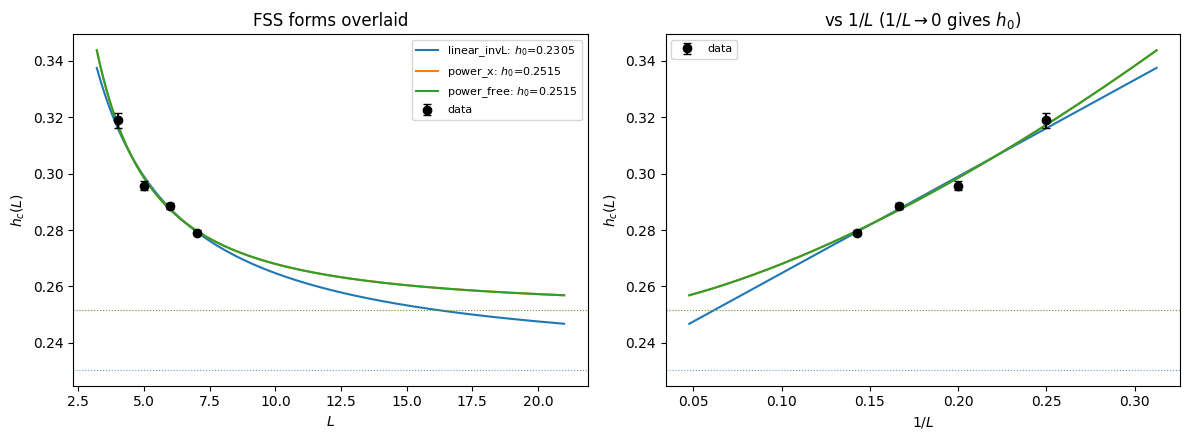

In [17]:
forms = ("linear_invL", "power_x", "power_free")
results = {f: fit_fss(fits, form=f, verbose=False) for f in forms}

print(f"{'form':>13} {'dof':>4} {'h_0':>9} {'h_0_err':>9}   params")
for f in forms:
    r = results[f]
    pstr = ("" if r["popt"] is None else
            ", ".join(f"{n}={float(v):.3g}" for n, v in zip(r["names"], r["popt"])))
    print(f"{f:>13} {r['dof']:>4} {r['h0']:>9.4f} {r['h0_err']:>9.4f}   {pstr}")

# fixed-exponent variants (free a dof at 3 L-points): common mean-field / Ising-ish x
print("\nfixed-exponent power_free (h0 + a*L**-w):")
for w in (1.0, 1.5, 2.0):
    r = fit_fss(fits, form="power_free", fix_x=w, verbose=False)
    print(f"   w={w:>3}:  h_0 = {r['h0']:.4f} ± {r['h0_err']:.4f}")

# ---- overlay all three fits (data shared across forms) ----
d = next(iter(results.values()))              # any result carries the same L, hc, he
col = {"linear_invL": "C0", "power_x": "C1", "power_free": "C2"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].errorbar(d["L"], d["hc"], yerr=d["he"], fmt="ko", capsize=3, zorder=5, label="data")
ax[1].errorbar(1.0 / d["L"], d["hc"], yerr=d["he"], fmt="ko", capsize=3, zorder=5, label="data")
for f in forms:
    r = results[f]
    if r.get("curve") is None:
        continue
    LL, cc = r["curve"]
    ax[0].plot(LL, cc, "-", color=col[f], label=f"{f}: $h_0$={r['h0']:.4f}")
    ax[0].axhline(r["h0"], ls=":", color=col[f], lw=0.8, alpha=0.7)
    ax[1].plot(1.0 / LL, cc, "-", color=col[f])
    ax[1].axhline(r["h0"], ls=":", color=col[f], lw=0.8, alpha=0.7)
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$", title="FSS forms overlaid"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title=r"vs $1/L$ ($1/L\to0$ gives $h_0$)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Jackknife h₀ (leave-one-L-out)

With only a handful of L-points, `curve_fit`'s covariance is thin. Refit `h_0`
dropping each L in turn — the spread of the jackknife replicates is an honest,
model-light stability check on `h_0` (and flags an L that's driving the answer).

Uses the **2-param `linear_invL`** form (`JK_FORM`) so each leave-one-out subset
(only 2 L-points) stays well-posed; a 3-param form would be underdetermined there.

In [18]:
JK_FORM = "linear_invL"    # 2 params -> each 2-point leave-one-out fit is well-posed
Ls_all = sorted(fits)
if len(Ls_all) >= 3:
    reps = []
    for drop in Ls_all:
        sub = [l for l in Ls_all if l != drop]
        r = fit_fss(fits, form=JK_FORM, use_Ls=sub, verbose=False)
        reps.append((drop, r["h0"]))
        print(f"  drop L={drop}: h_0 = {r['h0']:.4f}   (using L={sub})")
    vals = np.array([h for _, h in reps if np.isfinite(h)])
    full = fit_fss(fits, form=JK_FORM, verbose=False)["h0"]
    print(f"\n  [{JK_FORM}]  full-set h_0 = {full:.4f}   "
          f"jackknife mean = {vals.mean():.4f}   spread (std) = {vals.std(ddof=1):.4f}")
else:
    print("need >=3 L-points to jackknife")

  drop L=4: h_0 = 0.2364   (using L=[5, 6, 7])
  drop L=5: h_0 = 0.2260   (using L=[4, 6, 7])
  drop L=6: h_0 = 0.2298   (using L=[4, 5, 7])
  drop L=7: h_0 = 0.2327   (using L=[4, 5, 6])

  [linear_invL]  full-set h_0 = 0.2305   jackknife mean = 0.2312   spread (std) = 0.0044


## 8 · Compare to theory

Read the L→∞ extrapolation `h_0` against the known theoretical `h_c(hx=0)`. Set
`HZ_C_THEORY` to the thermodynamic-limit value. For each FSS form we report the
deviation `h_0 − theory` and its size in **σ**, folding the `curve_fit`
covariance and the jackknife spread in quadrature (both are thin at 4 L-points,
so read the σ as a rough — not rigorous — significance). The per-L table shows
the finite-size drift of the pseudo-critical `h_c(L)` that the extrapolation
removes; the plot marks `theory` as the red line the fits should hit at `1/L→0`.

In [19]:
# -- 8 - how close is the L->inf extrapolation to theory? ---------------------
HZ_C_THEORY = None      # <-- FILL IN: theoretical h_c at hx=0 (thermodynamic limit)

assert HZ_C_THEORY is not None, "set HZ_C_THEORY above (the theory value at hx=0)"

def _jk_spread(form):
    """leave-one-L-out spread of h_0 as a model-light error (needs >=3 L)."""
    Ls = sorted(fits)
    if len(Ls) < 3:
        return float("nan")
    reps = [fit_fss(fits, form=form, use_Ls=[l for l in Ls if l != d], verbose=False)["h0"]
            for d in Ls]
    reps = np.array([r for r in reps if np.isfinite(r)])
    return float(reps.std(ddof=1)) if len(reps) >= 2 else float("nan")

print(f"theory:  h_c(hx=0) = {HZ_C_THEORY:.4f}\n")
print(f"{'FSS form':>13} {'h_0':>8} {'fit_err':>8} {'jk_err':>7} {'h_0-thy':>9} {'n_sigma':>8}")
for f in ("linear_invL", "power_x", "power_free"):
    r = results[f]
    if r["popt"] is None or not np.isfinite(r["h0"]):
        print(f"{f:>13}   (fit failed)"); continue
    jk = _jk_spread(f)
    err = float(np.hypot(np.nan_to_num(r["h0_err"]), np.nan_to_num(jk)))  # fit + jk in quad
    dev = r["h0"] - HZ_C_THEORY
    nsig = abs(dev) / err if err > 0 else float("nan")
    print(f"{f:>13} {r['h0']:>8.4f} {r['h0_err']:>8.4f} {jk:>7.4f} {dev:>+9.4f} {nsig:>8.2f}")

print("\nper-L h_c(L) vs theory (pseudo-critical -- expect a finite-size drift):")
for l in sorted(fits):
    print(f"   L={l}:  h_c = {fits[l]['h_c']:.4f} +/- {fits[l]['h_c_err']:.4f}"
          f"   (h_c - thy = {fits[l]['h_c'] - HZ_C_THEORY:+.4f})")

# visual: FSS curves vs 1/L with the theory line at 1/L -> 0
fig, ax = plt.subplots(figsize=(6.8, 4.6))
d0 = next(iter(results.values()))
ax.errorbar(1.0 / d0["L"], d0["hc"], yerr=d0["he"], fmt="ko", capsize=3, zorder=5, label="data")
col = {"linear_invL": "C0", "power_x": "C1", "power_free": "C2"}
for f in ("linear_invL", "power_x", "power_free"):
    r = results[f]
    if r.get("curve") is None:
        continue
    LL, cc = r["curve"]
    ax.plot(1.0 / LL, cc, "-", color=col[f], label=f"{f}: $h_0$={r['h0']:.4f}")
    ax.axhline(r["h0"], ls=":", color=col[f], lw=0.8, alpha=0.6)
ax.axhline(HZ_C_THEORY, color="red", lw=1.8, label=f"theory = {HZ_C_THEORY:.4f}")
ax.axvline(0.0, color="gray", lw=0.5)
ax.set(xlabel="$1/L$", ylabel="$h_c(L)$", title="FSS extrapolation vs theory")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

AssertionError: set HZ_C_THEORY above (the theory value at hx=0)

## 9 · Data collapse (pyfssa)

Collapse `O_FM(hz)` for every L onto one master curve via the FSS ansatz
`A_L(hz) = L^(ζ/ν) · f̃( L^(1/ν) (hz − hz_c) )`. Where §5 used only each curve's
inflection (one number per L), this uses **every point of every curve** and
co-fits `(hz_c, ν, ζ)` by minimizing the Houdayer–Hartmann quality `S`
(`S ≈ 1` ⇒ curves collapse to within their error bars).

Three variants: the free 3-parameter fit, then **ν fixed** to 3D-Ising `0.63`
(ν is barely pinned by 4 sizes) and **ζ fixed = 0** (the crossing / RG-invariant
assumption — self-consistent here since the free fit returns ζ ≈ 0, i.e. the
O_FM curves cross at hz_c). Compare its `hz_c` against the §6 inflection `h_0`.

Needs `fssa` (`pip install 'fssa' 'setuptools<81'`); the shims at the top let the
unmaintained 0.7.6 import under NumPy 2 / SciPy ≥ 1.11.

/Users/sanzhar123/Desktop/Approximate-Symmetries-TC-main/.venv/lib/python3.13/site-packages/fssa/__init__.py:83: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


collapsing O over L=[4, 5, 6, 7] on 12 common hz [0.1, 0.375]

         variant     hz_c       nu     zeta       S
            free   0.2576   0.6779  -0.0004   3.048
      +/- (free)   0.0371   0.6022   0.0213
         nu=0.63   0.2598   0.6300  -0.0557   2.856
          zeta=0   0.2570   0.6851   0.0000   3.045


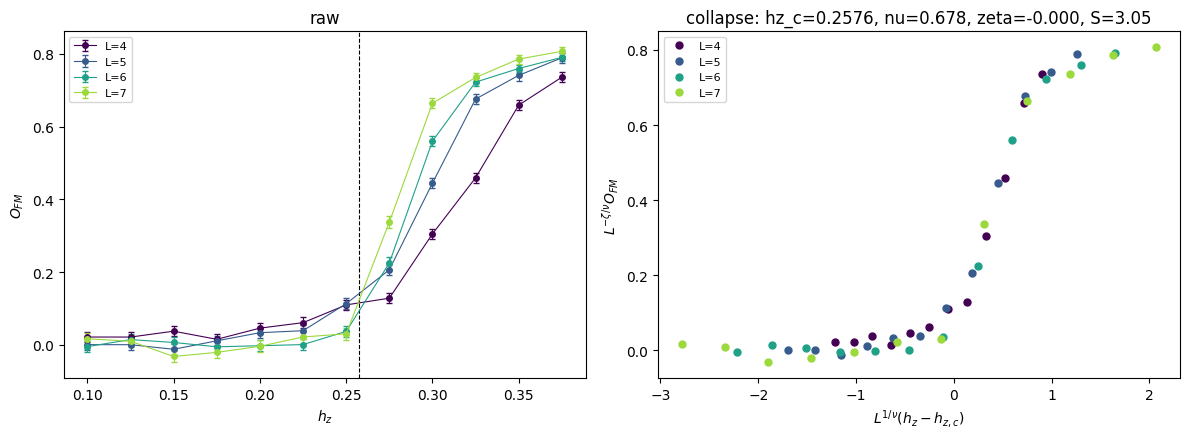

In [9]:
# ---- pyfssa data collapse of O_FM(hz). Compat shims first so the unmaintained
# ---- fssa 0.7.6 imports under NumPy 2 / SciPy >=1.11 (no-ops if already fine).
for _n, _t in {"int": int, "float": float, "bool": bool}.items():
    if not hasattr(np, _n): setattr(np, _n, _t)
if not hasattr(np, "asfarray"):
    np.asfarray = lambda _a, dtype=np.float64: np.asarray(_a, dtype=dtype)
import scipy.optimize.optimize as _oo
from scipy.optimize._optimize import _status_message as _sm
if not hasattr(_oo, "_status_message"): _oo._status_message = _sm
if not hasattr(_oo, "wrap_function"):
    def _wrap_function(function, args):
        ncalls = [0]
        if function is None: return ncalls, None
        def fw(*wa):
            ncalls[0] += 1; return function(*(wa + args))
        return ncalls, fw
    _oo.wrap_function = _wrap_function
try:
    import fssa
except ImportError:
    raise SystemExit("pip install 'fssa' 'setuptools<81'  # then restart the kernel")
from scipy.optimize import minimize

# ---- collapse config ----
RHO_C0, NU0, ZETA0 = 0.25, 0.63, 0.0     # initial guesses (rho_c ~ inflection h_0)
NU_FIXED = 0.63                          # 3D-Ising nu for the constrained refit

# ---- build the rectangular (L x hz) arrays on the hz grid common to every L ----
common = sorted(set.intersection(*[set(np.round(get_arrays(r)[0], 6)) for r in recs]))
l = np.array([r["L"] for r in recs], float)
rho = np.array(common, float)
a = np.zeros((len(l), len(rho))); da = np.zeros_like(a)
for i, r in enumerate(recs):
    hz_i, y_i, ye_i = get_arrays(r)
    idx = {round(float(h), 6): k for k, h in enumerate(hz_i)}
    for j, h in enumerate(common):
        k = idx[round(h, 6)]; a[i, j] = y_i[k]; da[i, j] = ye_i[k]
da = np.where(da > 0, da, np.nanmedian(da[da > 0]))     # floor zero/absent errors
print(f"collapsing {OBS} over L={[int(x) for x in l]} on {len(rho)} common hz "
      f"[{rho.min():.3g}, {rho.max():.3g}]")

def _qual(rho_c, nu, zeta):
    sc = fssa.scaledata(l, rho, a, da, rho_c, nu, zeta)
    return float(fssa.quality(sc.x, sc.y, sc.dy))

# free 3-parameter autoscale (rho_c, nu, zeta all fitted, with errors)
ret = fssa.autoscale(l, rho, a, da, RHO_C0, NU0, ZETA0)
# constrained refits (4 sizes -> free nu is loose): fix nu; and fix zeta=0 (crossing)
mnu = minimize(lambda p: _qual(p[0], NU_FIXED, p[1]), [RHO_C0, ZETA0], method="Nelder-Mead")
mz0 = minimize(lambda p: _qual(p[0], p[1], 0.0),      [RHO_C0, NU0],  method="Nelder-Mead")

print(f"\n{'variant':>16} {'hz_c':>8} {'nu':>8} {'zeta':>8} {'S':>7}")
print(f"{'free':>16} {ret.rho:>8.4f} {ret.nu:>8.4f} {ret.zeta:>8.4f} {ret.fun:>7.3f}")
print(f"{'+/- (free)':>16} {ret.drho:>8.4f} {ret.dnu:>8.4f} {ret.dzeta:>8.4f}")
print(f"{('nu=%.2f' % NU_FIXED):>16} {mnu.x[0]:>8.4f} {NU_FIXED:>8.4f} {mnu.x[1]:>8.4f} {mnu.fun:>7.3f}")
print(f"{'zeta=0':>16} {mz0.x[0]:>8.4f} {mz0.x[1]:>8.4f} {0.0:>8.4f} {mz0.fun:>7.3f}")

# cross-checks against the inflection FSS (section 6) and theory (section 8, if set)
try:
    print(f"\n  inflection FSS h_0 (linear_invL, section 6) = {results['linear_invL']['h0']:.4f}")
except (NameError, KeyError):
    pass
if "HZ_C_THEORY" in dir() and HZ_C_THEORY is not None:
    print(f"  theory hz_c = {HZ_C_THEORY:.4f}   (collapse free - theory = {ret.rho - HZ_C_THEORY:+.4f})")

# ---- plot: raw O_FM(hz) and the collapsed master curve at the free fit ----
sc = fssa.scaledata(l, rho, a, da, ret.rho, ret.nu, ret.zeta)
X, Y = np.asarray(sc.x), np.asarray(sc.y)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
cols = plt.cm.viridis(np.linspace(0, 0.85, len(l)))
for i, c in enumerate(cols):
    ax[0].errorbar(rho, a[i], yerr=da[i], fmt="-o", ms=4, capsize=2, lw=0.8, color=c,
                   label=f"L={int(l[i])}")
    ax[1].plot(X[i], Y[i], "o", ms=5, color=c, label=f"L={int(l[i])}")
ax[0].axvline(ret.rho, ls="--", color="k", lw=0.8)
ax[0].set(xlabel="$h_z$", ylabel=r"$O_{FM}$", title="raw"); ax[0].legend(fontsize=8)
ax[1].set(xlabel=r"$L^{1/\nu}(h_z-h_{z,c})$", ylabel=r"$L^{-\zeta/\nu}O_{FM}$",
          title=f"collapse: hz_c={ret.rho:.4f}, nu={ret.nu:.3f}, zeta={ret.zeta:.3f}, S={ret.fun:.2f}")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10 · Manual FSS — you supply h_c(L)

Drive the extrapolation by hand. **10a** prints the O_FM(hz) data and its
derivative per L as flat lists of dicts (`data_rows`, `deriv_rows`) so you can
read off / query any value; the steepest-descent hz is flagged as a candidate
`h_c(L)`. **10b** — you fill `HC_BY_L` with your eyeballed pseudo-critical field
per L and fit `h_c(L) = h_c(∞) + b·(1/L)^x`, with `x` **free** (bounded ≥ 0.1)
or **fixed** (`X_FIXED`). **10c** plots it (vs L and vs 1/L, with the `1/L→0`
extrapolation marked).

**Unweighted for now** — no error bars in the fit (we'll return to what
uncertainties to use; note L=4,5 have NaN `Oe` anyway). Caveat: the free 3-param
fit on 4 near-collinear points is loosely constrained — if `x` and `h_c(∞)` look
wild, pin `X_FIXED` (e.g. `1/ν ≈ 1.6` for 3D-Ising) and read `h_c(∞)` from there.

In [16]:
# ---- 10a · experimental input as flat lists of dicts (query freely) ----
#   e.g.   [d for d in data_rows if d["L"] == 6]
#          max((d for d in deriv_rows if d["L"] == 7), key=lambda d: abs(d["dO"]))
data_rows, deriv_rows = [], []
for r in recs:
    hz, O, Oe = get_arrays(r)                     # respects OBS/EXCLUDE/HZ_WINDOW
    dO = np.gradient(O, hz)                        # dO_FM/dhz at each hz
    for k in range(len(hz)):
        data_rows.append({"L": r["L"], "hz": round(float(hz[k]), 4),
                          "O": float(O[k]), "Oe": float(Oe[k])})
        deriv_rows.append({"L": r["L"], "hz": round(float(hz[k]), 4), "dO": float(dO[k])})

for r in recs:
    L = r["L"]
    print(f"\nL={L}:")
    ders = {d["hz"]: d["dO"] for d in deriv_rows if d["L"] == L}
    for d in (x for x in data_rows if x["L"] == L):
        print(f"   hz={d['hz']:<6} O={d['O']:+.4f}  Oe={d['Oe']:.4f}  dO/dhz={ders[d['hz']]:+.3f}")
    pk = max((d for d in deriv_rows if d["L"] == L), key=lambda d: abs(d["dO"]))
    print(f"   -> steepest descent at hz={pk['hz']} (|dO/dhz|={abs(pk['dO']):.3f})  <- candidate h_c(L)")


L=4:
   hz=0.1    O=+0.0212  Oe=nan  dO/dhz=-0.003
   hz=0.125  O=+0.0212  Oe=nan  dO/dhz=+0.321
   hz=0.15   O=+0.0373  Oe=nan  dO/dhz=-0.124
   hz=0.175  O=+0.0150  Oe=nan  dO/dhz=+0.169
   hz=0.2    O=+0.0457  Oe=nan  dO/dhz=+0.915
   hz=0.225  O=+0.0607  Oe=nan  dO/dhz=+1.276
   hz=0.25   O=+0.1095  Oe=nan  dO/dhz=+1.346
   hz=0.275  O=+0.1280  Oe=nan  dO/dhz=+3.903
   hz=0.3    O=+0.3047  Oe=nan  dO/dhz=+6.619
   hz=0.325  O=+0.4590  Oe=nan  dO/dhz=+7.083
   hz=0.35   O=+0.6589  Oe=nan  dO/dhz=+5.534
   hz=0.375  O=+0.7357  Oe=nan  dO/dhz=+2.660
   hz=0.4    O=+0.7918  Oe=nan  dO/dhz=+2.246
   -> steepest descent at hz=0.325 (|dO/dhz|=7.083)  <- candidate h_c(L)

L=5:
   hz=0.1    O=+0.0002  Oe=nan  dO/dhz=-0.003
   hz=0.125  O=+0.0002  Oe=nan  dO/dhz=-0.254
   hz=0.15   O=-0.0125  Oe=nan  dO/dhz=+0.213
   hz=0.175  O=+0.0108  Oe=nan  dO/dhz=+0.911
   hz=0.2    O=+0.0331  Oe=nan  dO/dhz=+0.557
   hz=0.225  O=+0.0387  Oe=nan  dO/dhz=+1.595
   hz=0.25   O=+0.1129  Oe=nan  dO/dhz=+3

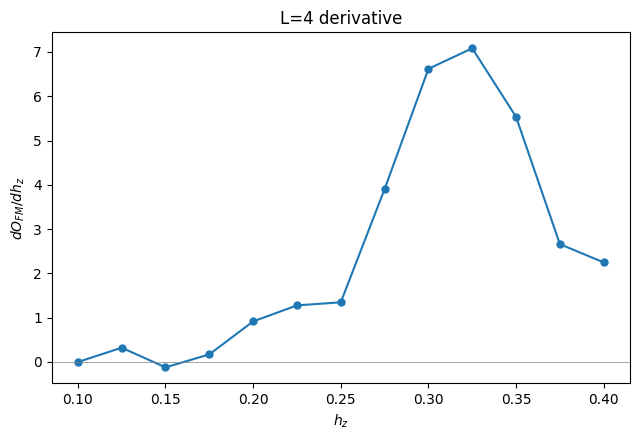

In [22]:
d4 = [d for d in deriv_rows if d["L"] == 4]
hz4 = [d["hz"] for d in d4]
dO4 = [d["dO"] for d in d4]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(hz4, dO4, "-o", ms=5)
ax.axhline(0, color="gray", lw=0.5)
ax.set(xlabel="$h_z$", ylabel="$dO_{FM}/dh_z$", title="L=4 derivative")
plt.tight_layout(); plt.show()

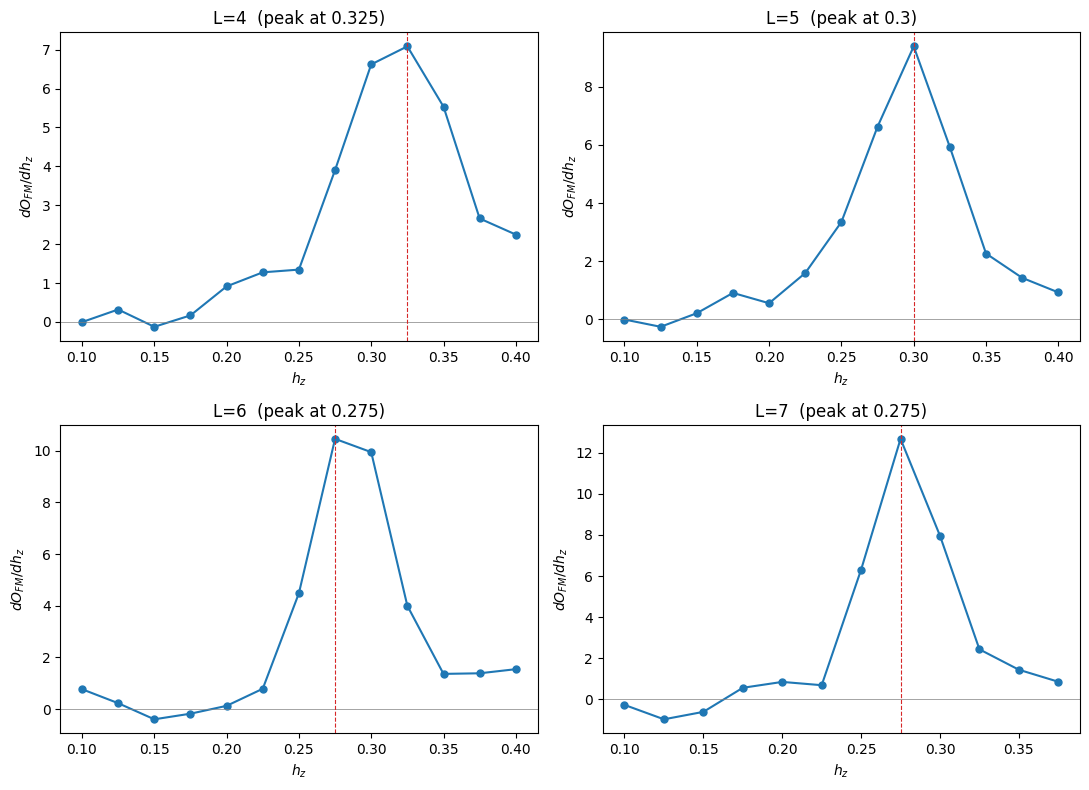

In [25]:
Ls = [4, 5, 6, 7]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for L, ax in zip(Ls, axes.flat):
    dL = [d for d in deriv_rows if d["L"] == L]     # derivative points for this L
    hz = [d["hz"] for d in dL]
    dO = [d["dO"] for d in dL]
    ax.plot(hz, dO, "-o", ms=5)
    ax.axhline(0, color="gray", lw=0.5)
    # mark the steepest point (candidate h_c)
    pk = max(dL, key=lambda d: abs(d["dO"]))
    ax.axvline(pk["hz"], ls="--", color="C3", lw=0.8)
    ax.set(xlabel="$h_z$", ylabel="$dO_{FM}/dh_z$", title=f"L={L}  (peak at {pk['hz']})")
fig.tight_layout()
plt.show()

In [31]:
# ---- 10b · YOU supply h_c(L); fit h_c(L) = h_c(inf) + b*(1/L)**x  (unweighted) ----
HC_BY_L = {4: 0.325, 5: 0.300, 6: 0.2875, 7: 0.275}   # <-- EDIT: your eyeballed h_c per L
X_FIXED = None       # None -> x free (bounded >=0.1); or a float to PIN the exponent

def hc_model(L, hc_inf, b, x):
    return hc_inf + b * (1.0 / np.asarray(L, float)) ** x

Lm  = np.array(sorted(HC_BY_L), float)
hcm = np.array([HC_BY_L[int(k)] for k in Lm])
if X_FIXED is None:
    # x free, but bounded away from 0: as x->0, (1/L)**x -> 1 and (hc_inf, b) stop being
    # separately identifiable (only their sum is), so an unbounded x lets hc_inf run off.
    popt, _ = curve_fit(hc_model, Lm, hcm, p0=[hcm.min(), 0.3, 1.5],
                        bounds=([-np.inf, -np.inf, 0.1], [np.inf, np.inf, 6.0]), maxfev=40000)
    hc_inf, b, x = map(float, popt)
else:
    g = lambda L, hc_inf, b: hc_model(L, hc_inf, b, X_FIXED)   # x pinned -> 2-param fit
    popt, _ = curve_fit(g, Lm, hcm, p0=[hcm.min(), 0.3], maxfev=40000)
    hc_inf, b, x = float(popt[0]), float(popt[1]), float(X_FIXED)

manual_fit = dict(hc_inf=hc_inf, b=b, x=x, L=Lm, hc=hcm)
print("input  h_c(L):  " + "  ".join(f"L{int(k)}={HC_BY_L[int(k)]}" for k in Lm))
print(f"best fit:  h_c(L) = {hc_inf:.4f} + ({b:.4f}) * (1/L)**{x:.4f}"
      f"   [x {'FIXED' if X_FIXED is not None else 'free'}]")
print(f"  ==>  h_c(inf) = {hc_inf:.4f}   (unweighted -- no error bars yet)")

input  h_c(L):  L4=0.325  L5=0.3  L6=0.2875  L7=0.275
best fit:  h_c(L) = 0.2262 + (0.5438) * (1/L)**1.2320   [x free]
  ==>  h_c(inf) = 0.2262   (unweighted -- no error bars yet)


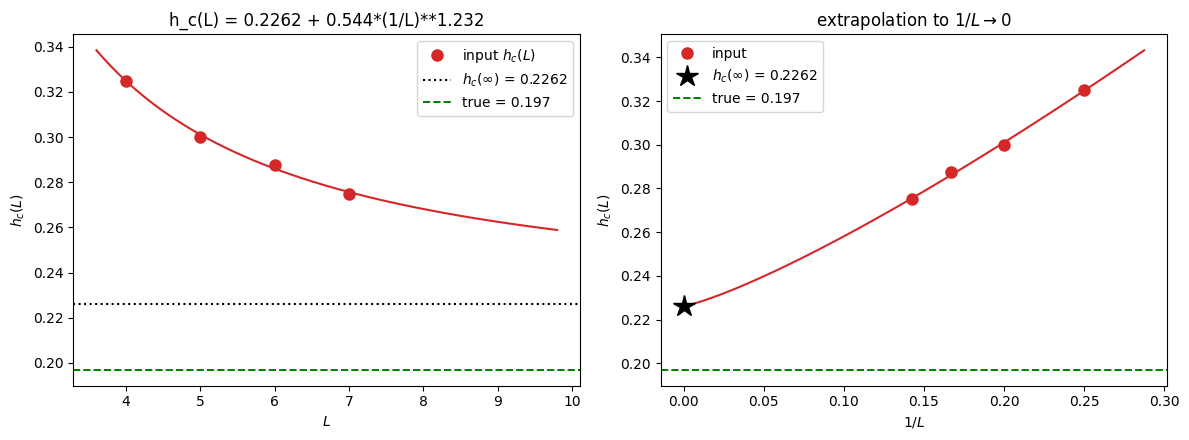

In [32]:
# ---- 10c · plot the manual fit (run section 10b first) ----
HZ_C_TRUE = 0.197        # theoretical h_c at hx=0 (thermodynamic limit)
mf = manual_fit
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
LL = np.linspace(mf["L"].min() * 0.9, mf["L"].max() * 1.4, 200)
ax[0].plot(mf["L"], mf["hc"], "o", ms=8, color="C3", label="input $h_c(L)$")
ax[0].plot(LL, hc_model(LL, mf["hc_inf"], mf["b"], mf["x"]), "-", color="C3")
ax[0].axhline(mf["hc_inf"], ls=":", color="k", label=f"$h_c(\\infty)$ = {mf['hc_inf']:.4f}")
ax[0].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"true = {HZ_C_TRUE}")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$",
          title=f"h_c(L) = {mf['hc_inf']:.4f} + {mf['b']:.3f}*(1/L)**{mf['x']:.3f}")
ax[0].legend()
invL = 1.0 / mf["L"]; g = np.linspace(0, invL.max() * 1.15, 200)
ax[1].plot(invL, mf["hc"], "o", ms=8, color="C3", label="input")
ax[1].plot(g, mf["hc_inf"] + mf["b"] * g ** mf["x"], "-", color="C3")
ax[1].plot(0, mf["hc_inf"], "*", ms=16, color="k", label=f"$h_c(\\infty)$ = {mf['hc_inf']:.4f}")
ax[1].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"true = {HZ_C_TRUE}")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title="extrapolation to $1/L\\to0$"); ax[1].legend()
plt.tight_layout(); plt.show()

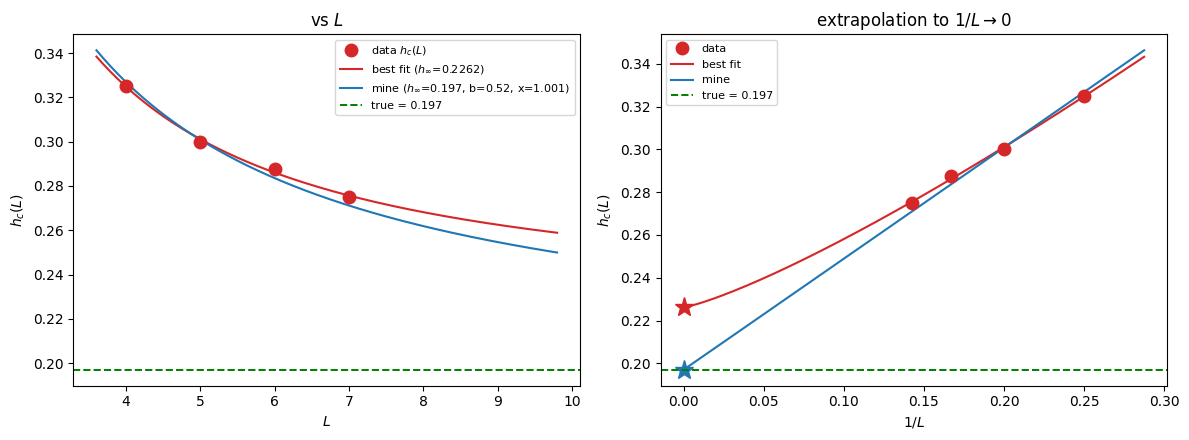

my curve:  h_inf=0.197  b=0.52  x=1.001
  intercept - true = +0.0000
  SSE vs data = 3.48e-05   per-L resid: L4=-0.0018, L5=-0.0008, L6=+0.0040, L7=+0.0039


In [51]:
# ---- 10d · overlay a HAND-SPECIFIED curve: data + best fit + true + your (h_inf, b, x) ----
#      tweak MY_* and re-run to see which parameters reproduce the 4 points AND hit the true line.
MY_HINF, MY_B, MY_X = 0.197, 0.52, 1.001     # <-- YOUR curve: h_c(L) = MY_HINF + MY_B*(1/L)**MY_X

HZ_C_TRUE = 0.197
mf = manual_fit
Lg = np.linspace(mf["L"].min() * 0.9, mf["L"].max() * 1.4, 200)
invL = 1.0 / mf["L"]; gg = np.linspace(0, invL.max() * 1.15, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
# left: vs L
ax[0].plot(mf["L"], mf["hc"], "o", ms=9, color="C3", zorder=5, label="data $h_c(L)$")
ax[0].plot(Lg, hc_model(Lg, mf["hc_inf"], mf["b"], mf["x"]), "-", color="C3",
           label=f"best fit ($h_\\infty$={mf['hc_inf']:.4f})")
ax[0].plot(Lg, hc_model(Lg, MY_HINF, MY_B, MY_X), "-", color="C0",
           label=f"mine ($h_\\infty$={MY_HINF}, b={MY_B}, x={MY_X})")
ax[0].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"true = {HZ_C_TRUE}")
ax[0].set(xlabel="$L$", ylabel="$h_c(L)$", title="vs $L$"); ax[0].legend(fontsize=8)
# right: vs 1/L (intercept at 1/L=0 is h_inf)
ax[1].plot(invL, mf["hc"], "o", ms=9, color="C3", zorder=5, label="data")
ax[1].plot(gg, mf["hc_inf"] + mf["b"] * gg ** mf["x"], "-", color="C3", label="best fit")
ax[1].plot(gg, MY_HINF + MY_B * gg ** MY_X, "-", color="C0", label="mine")
ax[1].plot(0, mf["hc_inf"], "*", ms=14, color="C3"); ax[1].plot(0, MY_HINF, "*", ms=14, color="C0")
ax[1].axhline(HZ_C_TRUE, ls="--", color="green", lw=1.4, label=f"true = {HZ_C_TRUE}")
ax[1].set(xlabel="$1/L$", ylabel="$h_c(L)$", title="extrapolation to $1/L\\to0$"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# how well does MY curve match the 4 points, and where does it extrapolate?
res = mf["hc"] - hc_model(mf["L"], MY_HINF, MY_B, MY_X)
print(f"my curve:  h_inf={MY_HINF}  b={MY_B}  x={MY_X}")
print(f"  intercept - true = {MY_HINF - HZ_C_TRUE:+.4f}")
print(f"  SSE vs data = {np.sum(res**2):.2e}   per-L resid: "
      + ", ".join(f"L{int(L)}={r:+.4f}" for L, r in zip(mf["L"], res)))

## 11 · Bootstrap the finite-difference peak → h_c(L) ± error

Locate `h_c(L)` as the peak of the finite-difference derivative (no sigmoid) and
error-bar it by resampling. For each L: draw `O ~ Normal(O, Oe)`, recompute
`dO/dhz`, and find the peak with a **3-point parabolic sub-grid vertex** (robust
to bin-hopping — it interpolates between the tied bins instead of jumping). The
spread of peak locations over `B_BOOT` resamples is the **statistical** σ.

Because the parabolic vertex is smooth, that statistical σ comes out *small* (≪
Δ/2). The honest error is then **systematic**: `|parabolic − raw-grid argmax|`,
which for a flat-topped peak is ≈ Δ/2 (= 0.0125) and typically *dominates*.
Builds `hc_boot[L] = (h_c, stat_sd, systematic)`. **L=4,5 are skipped** (NaN
`Oe`) until the FM extraction's error propagation is fixed.

In [ ]:
# ---- 11 · bootstrap the finite-difference peak -> h_c(L) with an error bar ----
# Resample O within its MC error, recompute dO/dhz, locate the peak with a 3-point
# parabolic sub-grid vertex. Spread over B_BOOT draws = STATISTICAL error. The gap
# |parabolic - raw-grid argmax| = SYSTEMATIC (estimator/grid) indicator -- for a
# flat-topped peak it's ~Delta/2 and usually the LARGER of the two. Needs finite Oe,
# so L=4,5 (NaN Oe) are skipped. Builds hc_boot[L] = (h_c, stat_sd, systematic).
B_BOOT = 4000
rng = np.random.default_rng(0)

def parabolic_peak(hz, y):
    """sub-grid |y|-peak via a 3-point parabolic vertex; falls back to the grid argmax."""
    a = np.abs(y); i = int(np.argmax(a)); D = hz[1] - hz[0]
    if 1 <= i <= len(a) - 2:
        ym1, y0, yp1 = a[i-1], a[i], a[i+1]; den = ym1 - 2*y0 + yp1
        if den < 0:                                   # concave -> genuine max
            return hz[i] + np.clip(0.5 * (ym1 - yp1) / den, -1, 1) * D
    return hz[i]

hc_boot = {}
print(f"{'L':>3} {'grid':>7} {'parab':>7} {'boot mu':>8} {'stat_sd':>8} "
      f"{'|par-grid|':>11} {'16-84%':>18}")
fig, axh = plt.subplots(figsize=(6.5, 4))
for r in recs:
    hz, O, Oe = get_arrays(r)
    if not np.all(np.isfinite(Oe)):
        print(f"{r['L']:>3}   -- Oe has NaN (extraction bug) -> no MC error bar --")
        continue
    grid = hz[int(np.argmax(np.abs(np.gradient(O, hz))))]
    parab = parabolic_peak(hz, np.gradient(O, hz))
    pk = np.array([parabolic_peak(hz, np.gradient(O + rng.normal(0, Oe), hz))
                   for _ in range(B_BOOT)])
    lo, hi = np.percentile(pk, [16, 84]); syst = abs(parab - grid)
    hc_boot[r["L"]] = (float(parab), float(pk.std()), float(syst))
    print(f"{r['L']:>3} {grid:>7.4f} {parab:>7.4f} {pk.mean():>8.4f} {pk.std():>8.4f} "
          f"{syst:>11.4f}   [{lo:.4f}, {hi:.4f}]")
    axh.hist(pk, bins=40, alpha=0.6, label=f"L={r['L']}")
axh.set(xlabel="bootstrap peak $h_c(L)$", ylabel="count",
        title=f"peak-location bootstrap (B={B_BOOT})"); axh.legend()
plt.tight_layout(); plt.show()

print("\nhc_boot[L] = (h_c, statistical_sd, systematic |parab-grid|)")
print("  -> for a weighted FSS use e.g. sigma = hypot(stat_sd, systematic);")
print("     for a flat-topped peak the systematic (~Delta/2 = 0.0125) dominates.")